# Mission 5 
#### Dev, Darren & Vandana

### Task 4: Load the Dataset

To start our analysis we will need to import the data from ANZ bank. To do this we need to install azure-storage-blob and connect to the blob client



In [16]:
!pip install azure-storage-blob

In [15]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"

container_name = "businesscases"
blob_name = "Final_Mission_loan_data.csv"

blob_service_client = BlobServiceClient.from_connection_string(connect_str)
blob_client = blob_service_client.get_blob_client(container=container_name, blob=blob_name)

In [17]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

blob_data = blob_client.download_blob().content_as_text()

df = pd.read_csv(StringIO(blob_data))

df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


Above it looks like the importing was successful. There are columns and rows of data which we can see that corresponds to customer demographic information and, importantly, that they had loans (loan_amnt) and whether they defaulted on that loan or not (loan_status)

In [18]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 14.5 MB/s eta 0:00:00


We will need to see what we are working with in terms of how much data, and whether there are missing values or not.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


### Task 5: Perform Exploratory Data Analysis (EDA)

#### **Missing Values**

In [21]:
# Check for missing values
print(f"Missing values in each column:\n{df.isnull().sum()}")

# Check the data types of each column
print(f"Data types:\n{df.dtypes}")

Missing values in each column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
Data types:
person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_

It looks good, there is no missing values in the various columns. But will run a df.info just to make sure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

There are 45,000 non-null entries in the 14 different columns. We can work with this data as there is no missing values. So we will do some graphs so we can visualise the distribution of the loan amounts.

### Distribution of Loan Amounts

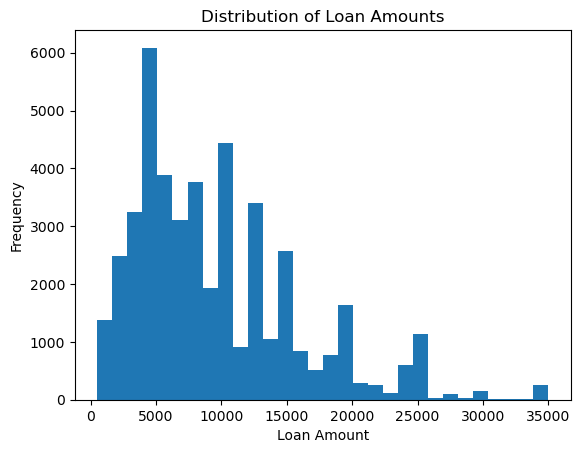

In [23]:
plt.figure()
plt.hist(df['loan_amnt'], bins=30)
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

### Distribution of Credit Scores

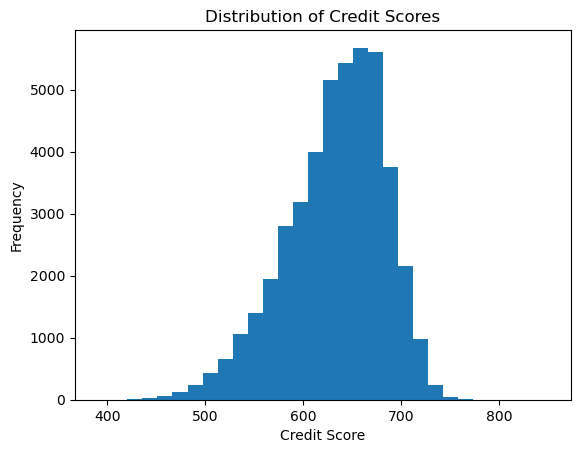

In [ ]:
plt.figure()
plt.hist(df['credit_score'].dropna(), bins=30)
plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()


Retrospective:
The above show a distribution of Loan Amounts and Credit Scores. But, its good that we can see a majority of credit scores around the 650-700 mark, and a loan peak of $5000. However, the graph merges all the bars together as an odd blob of information that is not easily read.

Lets Respond To Change here and change our thinking on the graphs. We need to have a small gap between the individual bars so the various values can be more easily distinguished. Adding grid lines will also allow an easy identifier on the Y axis.

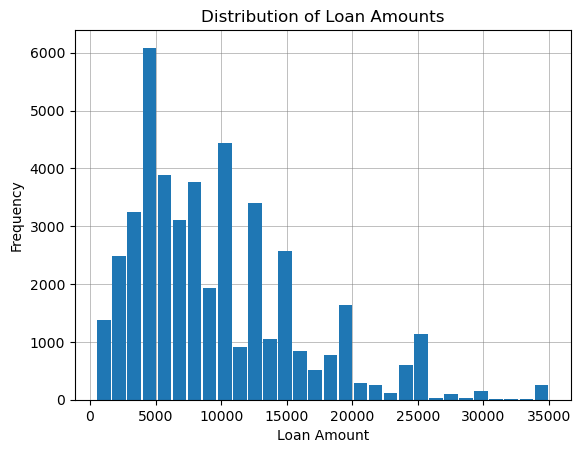

In [ ]:
plt.figure()
plt.hist(df['loan_amnt'], bins=30, rwidth=0.9)
plt.grid(axis='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

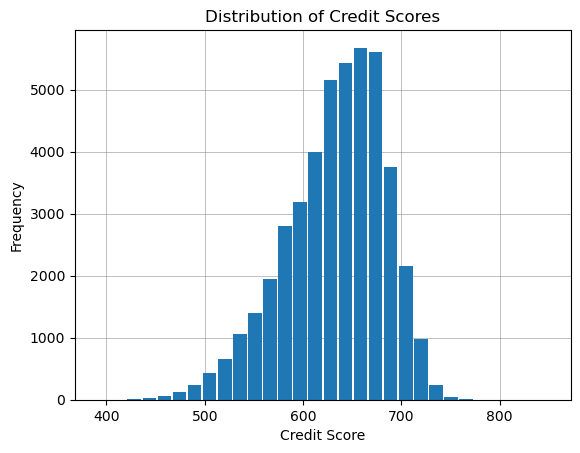

In [18]:
plt.figure()
plt.hist(df['credit_score'], bins=30, rwidth=0.9)
plt.grid(axis='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

This is more easily read now. There is a peak of $5000 loans that then trails down towards $35000, with high peaks at $5000 intervals. Definately a down-ward heading trend.
Similarily, we can easily see a majority of credit scores are in the 600-700 range. With very little after 700 and a high-curve from about 420-approx 670

### Distribution of Loan Status

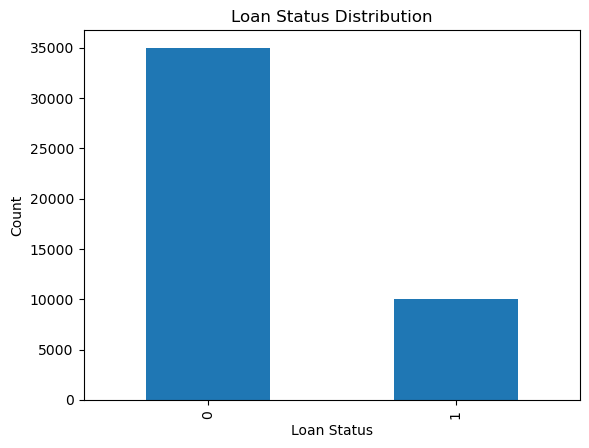

In [24]:
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

This is, perhaps, the main graph that ANZ will want to focus on - and something we will need to present in our findings. We can empathise with the banks desire to reduce defaulting and the above shows 1000 defaulted loans.
Importantly, we should figure out what that equates to in an actual dollar figure:

In [ ]:
defaults = df[df['loan_status'] == 1]

print(f"Count of defaults: {len(defaults)}")
print(f"Total loan amount: ${defaults['loan_amnt'].sum():,}")

Count of defaults: 10000
Total loan amount: $108,556,898


$108 million in defaulted loans is an enormous expense.

Lets see if we can run a correlation matrix to indicate if there is any correlations in customer demographics to indicate if they will default or not.

In [20]:
df_encoded = df.copy()

df_encoded = pd.get_dummies(df_encoded, drop_first=True)

In [21]:
correlation = df_encoded.corr()

correlation['loan_status'].sort_values(ascending=False)

NameError: name 'df_encoded' is not defined

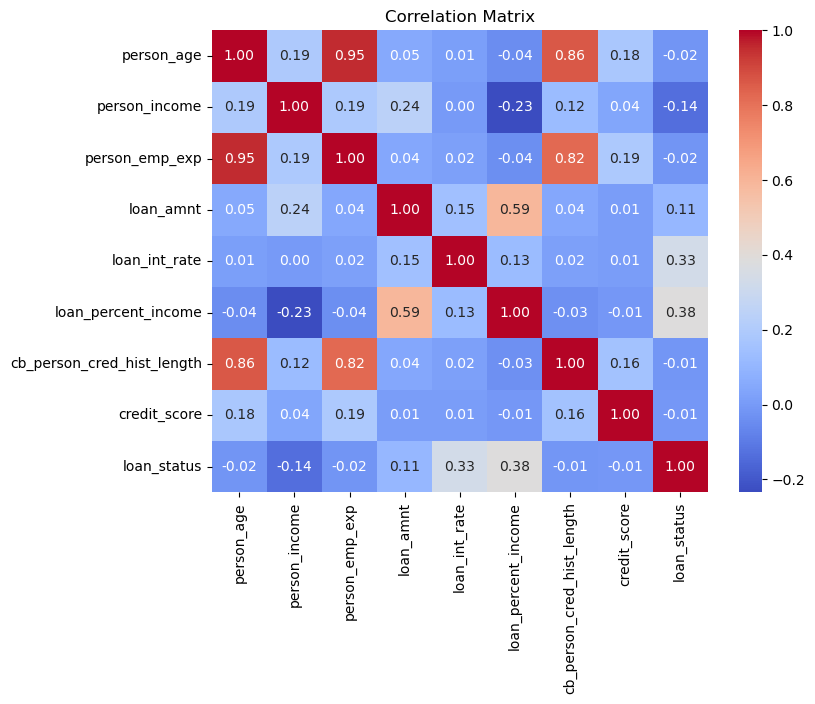

In [25]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

There is a definite correlation between a customers income to a loan percentage, as well as the interest rate of the loan, as well as a slight correlation between the loan amount and the chances of a customer defaulting. Interestingly: a persons age, credit score, length of credit history, and years of employment experience seem to have little correlation on whether a customer is likely to default or not. That means there the best indication is to judge their current income level (a higher income is shown to have a negative correlation on defaulting) vs the loan requested and interest rate to see if a customer would default or not. 

### Task 6: Data Preprocessing

We will now try and make different prediction models. We need to encode the categorical columns, and then make the data into the 'y' column (loan_status) and the 'X' column (everything else). We can then separate this into a 'training set' and a 'testing set' so that we can test the various models accuracy. 

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Encode categorical columns
df['person_gender'] = label_encoder.fit_transform(df['person_gender'])
df['person_education'] = label_encoder.fit_transform(df['person_education'])
df['person_home_ownership'] = label_encoder.fit_transform(df['person_home_ownership'])
df['loan_intent'] = label_encoder.fit_transform(df['loan_intent'])

# Encode target variable
df['loan_status'] = label_encoder.fit_transform(df['loan_status'])

In [29]:
X = df[['person_age',
        'person_income',
        'person_emp_exp',
        'loan_amnt',
        'loan_int_rate',
        'loan_percent_income',
        'credit_score',
        'cb_person_cred_hist_length',
        'person_gender',
        'person_education',
        'person_home_ownership',
        'loan_intent']]

y = df['loan_status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (36000, 12)
Testing set: (9000, 12)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the split data
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")


Training Data: (36000, 12), Testing Data: (9000, 12)


### **Task 7: Train the Multiple Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train Logistic Regression model
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)


# Predict test data
y_pred = log_model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

🏃 View run lucid_pot_8760mq19 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/22e6e31a-eb17-4a43-9d7b-ed478e7bef97/runs/7dead845-e275-4e0d-bb0a-273efd323aa9
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/22e6e31a-eb17-4a43-9d7b-ed478e7bef97


Model Accuracy: 0.8231111111111111


### **Task 7: Train the Random Forest Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy: {accuracy_rf}")


🏃 View run olden_chain_6bvdz1dk at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/22e6e31a-eb17-4a43-9d7b-ed478e7bef97/runs/afa665b1-c95f-4455-a08f-ca4413d14bb4
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/22e6e31a-eb17-4a43-9d7b-ed478e7bef97


Random Forest Model Accuracy: 0.9062222222222223


### **Task 7: Train the Gradient Boosting Model**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Model Accuracy: {accuracy_gb}")

🏃 View run tough_seed_1975zxw4 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/22e6e31a-eb17-4a43-9d7b-ed478e7bef97/runs/11ae729e-3e8c-4eed-80b7-bf7003d68a75
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/c4e27282-9e96-47bd-a30d-8b594a6b9677/#/experiments/22e6e31a-eb17-4a43-9d7b-ed478e7bef97


Gradient Boosting Model Accuracy: 0.9001111111111111


The numbers are close, with Random Forest edging out Gradient Boosting slightly with accuracy, and the Logistic Regression reasonably far behind in third. We would feel confident in recommending either, but should compare them to see where they are going and where they are failing

In [ ]:
comparison_table = pd.DataFrame({
    'Actual': y_test,
    'Logistic_Regression': y_pred,
    'Random_Forest': y_pred_rf,
    'Gradient_Boosting': y_pred_gb
})

print(comparison_table.head())

       Actual  Logistic_Regression  Random_Forest  Gradient_Boosting
37979       0                    0              0                  0
9911        0                    0              0                  0
43386       1                    1              1                  1
13822       0                    0              0                  0
44810       1                    0              0                  1


Retrospective:
The above shows that the Gradient Boosting accurately predicted a default on line 44810, whereas the others missed it. Otherwise, this small sample seems to indicate that the three models predicted the actual result each time. The Logistic Regression performed poorly over the 3 models at 82.3% accuracy so we can dismiss this as a prediction model.

The Random Forest slightly edges the Gradient Boosting in accuracy by 0.05% 

Empathetically, we should consider what would be bad for the bank. Approving a loan that defaults hurts the bank financially and incurs an expense 'bad debt' that lowers profitability. However, if it predicts that a customer would default wherein they actual would repay the loan loses the bank both revenue and a potential repeat customer.

We should run a Confusion Matrix to see what the false negatives and false positives are for the three models so as we can better recommend a model over the others

**Confusion Matrix**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Accuracy
accuracy_log = accuracy_score(y_test, y_pred)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Accuracy Scores:")
print(f"Logistic Regression: {accuracy_log}")
print(f"Random Forest: {accuracy_rf}")
print(f"Gradient Boosting: {accuracy_gb}")

# Confusion Matrices
print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nGradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy Scores:
Logistic Regression: 0.8231111111111111
Random Forest: 0.9062222222222223
Gradient Boosting: 0.9001111111111111

Logistic Regression Confusion Matrix:
[[6611  379]
 [1213  797]]

Random Forest Confusion Matrix:
[[6855  135]
 [ 709 1301]]

Gradient Boosting Confusion Matrix:
[[6817  173]
 [ 726 1284]]


The Confusion Matrix is clear here. Despite Random Forest and Gradient Boosting having higher accuracy scores, the Gradient Boosting predicted 17 more false negatives and 38 more false positives over the random forest. 

To empathise with ANZ's position - every additional false negative is an extra cost incurred by the business and 17 extra predictions on the training data would balloon to higher numbers the more loans that ANZ approve. Worrilngly though, are the 38 more false positives as these equate to lost profit and could even result in lost future business if those customers go to a rival bank.

In [ ]:
print("-" * 120)

------------------------------------------------------------------------------------------------------------------------


Task 11: Conclusion.

With the performance of the models it is clear that the Random Forest is the best performing model, accurately predicting the most true positives at 1301 and then followed by Gradient Boosting and lastly Logistic Regression. 

This is important information for our client, the ANZ Bank. We can empathise with their desire to be as accurate as possible to being able to conclude with high likelihood the certainty of a customer defaulting on their loan or not. Financially, every defaulted loan is an expense that the bank would like to minimise. Likewise, any customers who were unapproved for a loan that would have paid it off represents both lost revenue and potentially a lost customer as they go to a rival for all their banking needs.

The Logistic Regression showed the most false negatives at 1213. This is an expense ("Bad debt") and high cost for the bank which would affect their profit. It is important to keep these costs to a minimum and why we cannot recommend the Logistic Regression model.

The Gradient Boosting model and Random Forest model had similar accuracy - with only 0.05% between them - and both being above 90% which would make them fairly accurate models for the purposes of ANZ. But when comparing the confusion matrixes the Random Forest beats the Gradient Boosting model in every category. This results in the least defaullted loans, the most repaid loans, and the best profitability for the bank.

It is for the above we approve the Random Forest for use by ANZ for predicting whether a customer would be able to pay back their loan or not. Having the least false negatives would minimise their expense of 'bad debts', and a lower false positive achieves customer retention and keeps them for any future banking endeavours.


In [ ]:
import pandas as pd

df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

df_results.head()

,Actual,Predicted
37979,0,0
9911,0,0
43386,1,1
13822,0,0
44810,1,0


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

df_results_spark = spark.createDataFrame(df_results)



Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/13 05:03:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/13 05:03:42 WARN SparkContext: Exception when load sparklyr connector java.lang.ClassNotFoundException: org.apache.spark.sparklyr.DefaultConnector


In [ ]:
df_results_spark.createOrReplaceTempView("df_results_spark_view")

df_results_spark = spark.createDataFrame(df_results)

df_results_spark.createOrReplaceTempView("df_results_spark_view")

df_spark= spark.table("df_results_spark_view")

df_spark.write.mode("overwrite") \
.option("overwriteSchema", "true") \
.saveAsTable("Team1_Mission5_Table")

26/03/13 05:03:55 WARN SQLConf: Cannot load HintErrorHandler org.apache.spark.sql.catalyst.analysis.HintErrorLogger for exception: org.apache.spark.sql.catalyst.analysis.HintErrorLogger.<init>(), callStack: [Ljava.lang.StackTraceElement;@34ab6277, load the default HintErrorLogger
26/03/13 05:03:56 WARN SQLConf: Cannot load HintErrorHandler org.apache.spark.sql.catalyst.analysis.HintErrorLogger for exception: org.apache.spark.sql.catalyst.analysis.HintErrorLogger.<init>(), callStack: [Ljava.lang.StackTraceElement;@76b90bb3, load the default HintErrorLogger
